In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [6]:
df = pd.read_csv("/kaggle/input/datasets/ishita1kumari/manufacturing-dataset/manufacturing_downtime_dataset.csv")

In [7]:
df.head()

,machine_id,timestamp,air_temperature,process_temperature,rotational_speed,torque,vibration,pressure,tool_wear,failure_type,machine_failure,downtime_minutes,maintenance_type,production_output,maintenance_cost,shift,operator_id
0,M11,23-03-2025 01:39,25.49,37.21,1694,55.23,2.27,86.49,6,No Failure,0,7,Preventive,294,385,Day,OP044
1,M12,05-03-2025 07:21,28.74,42.27,1359,45.43,2.04,83.01,151,No Failure,0,0,Preventive,227,547,Day,OP033
2,M10,20-01-2025 07:44,24.73,32.90,982,34.38,1.49,94.71,143,No Failure,0,13,Preventive,292,1019,Night,OP001
3,M13,27-04-2025 06:14,21.28,30.46,1939,37.74,2.57,68.63,178,No Failure,0,8,Preventive,259,540,Night,OP007
4,M02,04-10-2025 15:42,22.37,34.59,1154,43.76,1.90,85.62,24,No Failure,0,11,Preventive,489,641,Day,OP047


In [8]:
df.isnull().sum()

machine_id             0
timestamp              0
air_temperature        0
process_temperature    0
rotational_speed       0
torque                 0
vibration              0
pressure               0
tool_wear              0
failure_type           0
machine_failure        0
downtime_minutes       0
maintenance_type       0
production_output      0
maintenance_cost       0
shift                  0
operator_id            0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
X = df[
    [
        'vibration',
        'pressure',
        'torque',
        'process_temperature'
    ]
]

In [11]:
y = df['machine_failure']

In [12]:
print(y.value_counts())

machine_failure
0    10222
1     1778
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print(X_train.shape)
print(X_test.shape)

(9600, 4)
(2400, 4)


In [15]:
lr_model = LogisticRegression()

In [17]:
lr_model.fit(X_train, y_train)

LogisticRegression()

In [18]:
lr_predictions = lr_model.predict(X_test)

In [20]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Accuracy:", lr_accuracy)

Accuracy: 0.8504166666666667


In [21]:
print(
    confusion_matrix(
        y_test,
        lr_predictions
    )
)

[[2035   10]
 [ 349    6]]


In [22]:
print(
    classification_report(
        y_test,
        lr_predictions
    )
)

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2045
           1       0.38      0.02      0.03       355

    accuracy                           0.85      2400
   macro avg       0.61      0.51      0.48      2400
weighted avg       0.78      0.85      0.79      2400



In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [24]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [25]:
rf_predictions = rf_model.predict(X_test)

In [26]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Accuracy:", rf_accuracy)

Accuracy: 0.845


In [27]:
print(
    confusion_matrix(
        y_test,
        rf_predictions
    )
)

[[1972   73]
 [ 299   56]]


In [28]:
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2045
           1       0.43      0.16      0.23       355

    accuracy                           0.84      2400
   macro avg       0.65      0.56      0.57      2400
weighted avg       0.80      0.84      0.81      2400



In [29]:
print("Logistic Regression:", lr_accuracy)
print("Random Forest:", rf_accuracy)

Logistic Regression: 0.8504166666666667
Random Forest: 0.845


In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

               Feature  Importance
3  process_temperature    0.269211
0            vibration    0.248253
1             pressure    0.244224
2               torque    0.238313


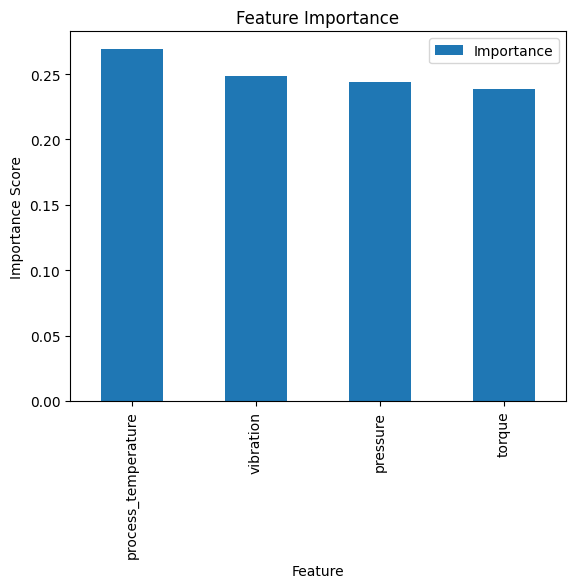

In [31]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

In [32]:
accuracy_score(
    y_test,
    rf_predictions
)

0.845

In [33]:
confusion_matrix(
    y_test,
    rf_predictions
)

array([[1972,   73],
       [ 299,   56]])

In [34]:
classification_report(
    y_test,
    rf_predictions
)

'              precision    recall  f1-score   support\n\n           0       0.87      0.96      0.91      2045\n           1       0.43      0.16      0.23       355\n\n    accuracy                           0.84      2400\n   macro avg       0.65      0.56      0.57      2400\nweighted avg       0.80      0.84      0.81      2400\n'